# 📈 Taller: Modelos de series de tiempo multivaridas
---
**Maestría en Inteligencia de Negocios** - *Universidad Externado de Colombia*

| | |
| :--- | :--- |
| **Materia:** | Series de Tiempo |
| **Elaborado por:** | Diego Hernando Miranda Jimenez |
| | Juan Sebastian Angel Perez |
| **Fecha:** | abril 2026 |

---

## 1. Descripción de las Series de Tiempo

Para el desarrollo de este taller, se han seleccionado tres indicadores macroeconómicos clave de los Estados Unidos, obtenidos a través de la base de datos **FRED**. Estas variables permitirán analizar las interrelaciones dinámicas mediante modelos **VAR** y **VEC**.

### 📊 Variables Seleccionadas

| Variable | Sigla (FRED) | Descripción | Frecuencia | Inicio | Finalización | Unidad |
| :--- | :---: | :--- | :---: | :---: | :---: | :--- |
| **Producto Interno Bruto** | `GDP` | Valor de mercado de los bienes y servicios finales producidos. | Trimestral | Q1 - 1947 | Q4 - 2025 | Billones de USD |
| **Tasa Natural de Desempleo** | `NROU` | Tasa de desempleo consistente con inflación estable (NAIRU). | Trimestral | Q1 - 1949 | Q4 - 2036 (Proyectado)| Porcentaje |
| **Inflación (IPC)** | `CPALTT01USQ657N` | Índice de Precios al Consumidor (Base OCDE). | Trimestral | Q2 - 1955 | Q1 - 2024 | Crecimiento % |

*\*Nota: Las fechas finales pueden variar según la última actualización disponible en el servidor de la FRED al momento de la descarga.*

### 🔍 Consideraciones para el Modelado
Dado que las series poseen distintas fechas de inicio, se realizará un truncamiento de la muestra para iniciar el análisis en **1957-Q1** hasta el **2023-Q4**. Asimismo, se evaluará la necesidad de aplicar logaritmos al `GDP` para linealizar su tendencia antes de realizar las pruebas de cointegración necesarias para el modelo VEC.

## 2. Importación de librerias y configuraciones


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf

## 3. Lectura de datos


In [52]:
# Lectura de archivos
df_GDP = pd.read_csv('../Datos/GDP.csv')
df_GDP['observation_date'] = pd.to_datetime(df_GDP['observation_date'])

df_CPALT = pd.read_csv('../Datos/CPALTT01USQ657N.csv')
df_CPALT['observation_date'] = pd.to_datetime(df_CPALT['observation_date'])

df_NROU = pd.read_csv('../Datos/NROU.csv')
df_NROU['observation_date'] = pd.to_datetime(df_NROU['observation_date'])

In [53]:
# Unir los DataFrames usando la columna 'observation_date'
# Usamos 'how=inner' para que solo queden fechas presentes en los tres archivos
df= df_GDP.merge(df_CPALT, on='observation_date', how='inner') \
                 .merge(df_NROU, on='observation_date', how='inner')

# 3. Renombrar para mayor claridad
df.columns = ['Fecha', 'GDP', 'CPI_Inflation', 'NROU']

# Visualizar el resultado
df.head(10)

,Fecha,GDP,CPI_Inflation,NROU
0,1955-04-01,421.532,0.000000,5.383725
1,1955-07-01,430.221,0.499376,5.386171
2,1955-10-01,437.092,0.124224,5.388586
3,1956-01-01,439.746,-0.248139,5.390996
4,1956-04-01,446.010,0.870647,5.393430
5,1956-07-01,451.191,1.233046,5.395917
6,1956-10-01,460.463,0.609013,5.398493
7,1957-01-01,469.779,0.605327,5.401198
8,1957-04-01,472.025,1.083032,5.404080
9,1957-07-01,479.490,1.071429,5.407185


In [54]:
df["Fecha"].unique()

<DatetimeArray>
['1955-04-01 00:00:00', '1955-07-01 00:00:00', '1955-10-01 00:00:00',
 '1956-01-01 00:00:00', '1956-04-01 00:00:00', '1956-07-01 00:00:00',
 '1956-10-01 00:00:00', '1957-01-01 00:00:00', '1957-04-01 00:00:00',
 '1957-07-01 00:00:00',
 ...
 '2021-10-01 00:00:00', '2022-01-01 00:00:00', '2022-04-01 00:00:00',
 '2022-07-01 00:00:00', '2022-10-01 00:00:00', '2023-01-01 00:00:00',
 '2023-04-01 00:00:00', '2023-07-01 00:00:00', '2023-10-01 00:00:00',
 '2024-01-01 00:00:00']
Length: 276, dtype: datetime64[ns]

In [55]:
#Eliminar los tres primeros registros del df, para que la serie arranque en el año 1956
df = df.iloc[3:]
#Eliminar el ultimo registro del df, para que la serie termine en el año 2023
df = df.iloc[:-1]

In [56]:
df

,Fecha,GDP,CPI_Inflation,NROU
3,1956-01-01,439.746,-0.248139,5.390996
4,1956-04-01,446.010,0.870647,5.393430
5,1956-07-01,451.191,1.233046,5.395917
6,1956-10-01,460.463,0.609013,5.398493
7,1957-01-01,469.779,0.605327,5.401198
...,...,...,...,...
270,2022-10-01,26770.514,0.367161,4.437232
271,2023-01-01,27216.445,1.044907,4.435296
272,2023-04-01,27530.055,1.192332,4.433510
273,2023-07-01,28074.846,0.866427,4.431368


In [57]:
# Crear un índice de tiempo trimestral comenzando en 1956-Q1
# Nota: La longitud del rango de fechas debe coincidir con el número de filas en 'df'
time_index = pd.date_range(start='1956-01-01', periods=len(df), freq='Q')

# Asignar este índice de tiempo al DataFrame
df.index = time_index

C:\Users\inter\AppData\Local\Temp\ipykernel_20796\217004516.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  time_index = pd.date_range(start='1956-01-01', periods=len(df), freq='Q')


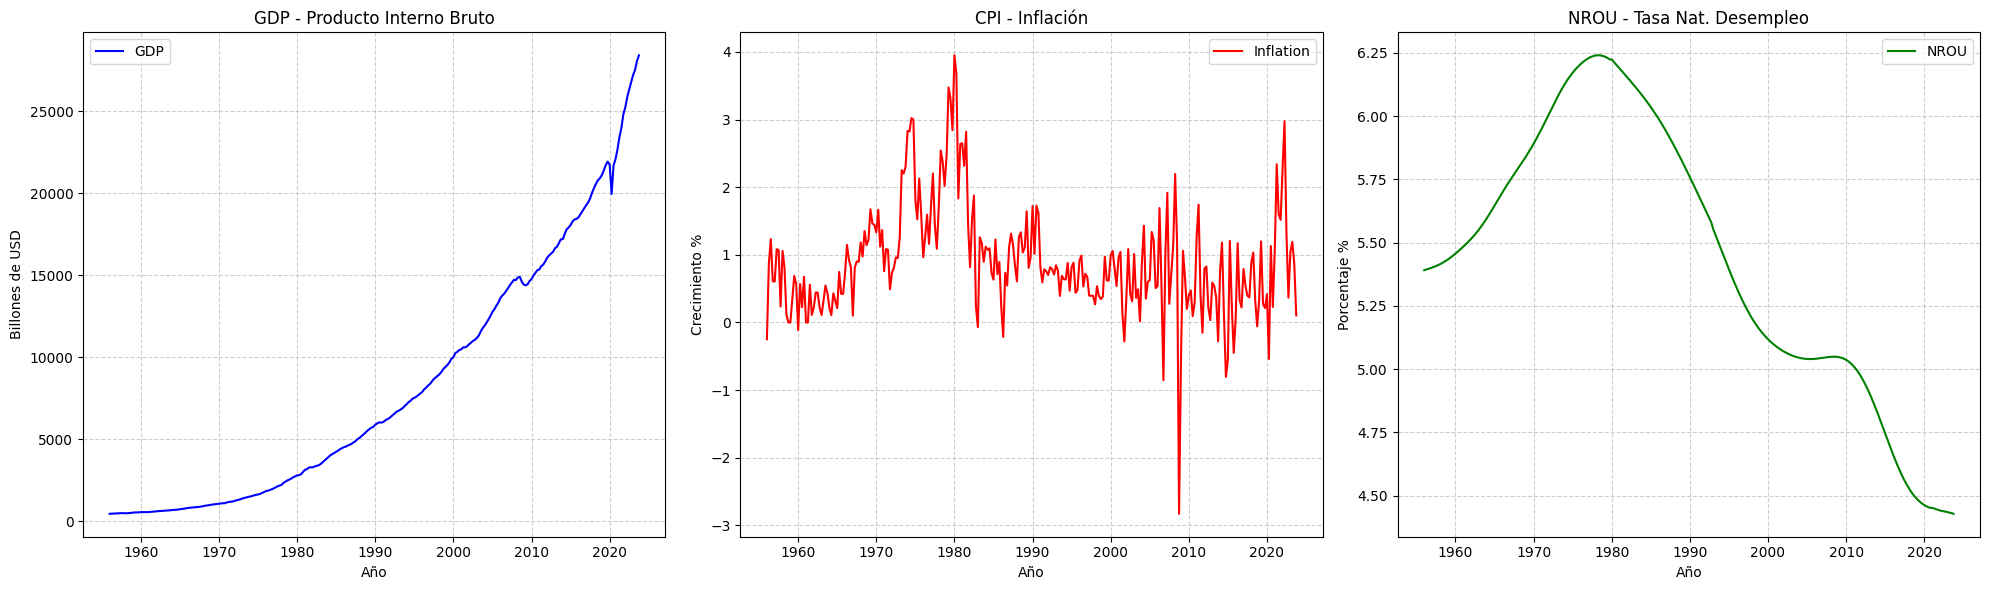

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Graficando GDP (Producto Interno Bruto)
axes[0].plot(df['Fecha'], df['GDP'], color='blue', label='GDP')
axes[0].set_title('GDP - Producto Interno Bruto')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Billones de USD')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2. Graficando CPI_Inflation (Inflación)
axes[1].plot(df['Fecha'], df['CPI_Inflation'], color='red', label='Inflation')
axes[1].set_title('CPI - Inflación')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Crecimiento %')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 3. Graficando NROU (Tasa Natural de Desempleo)
axes[2].plot(df['Fecha'], df['NROU'], color='green', label='NROU')
axes[2].set_title('NROU - Tasa Nat. Desempleo')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Porcentaje %')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

# Ajuste automático de espaciado entre subplots
plt.tight_layout()

# Mostrar el resultado final
plt.show()

**Paso1. Verificar si las series son estacionarias**
Ho: Hay raiz unitaria. La serie no es estacionaria
H1: La serie es estacionaria

In [59]:
for column in ['GDP', 'CPI_Inflation', 'NROU']:
    result = adfuller(df[column], autolag='AIC', regression='ct')
    print(f"ADF Statistic for {column}: {result[0]}")
    print(f"p-value for {column}: {result[1]}")

ADF Statistic for GDP: 3.128527128694977
p-value for GDP: 1.0
ADF Statistic for CPI_Inflation: -2.5259612138009278
p-value for CPI_Inflation: 0.3151064805090008
ADF Statistic for NROU: -2.596750749128473
p-value for NROU: 0.2813905525543585


Al aplicar la prueba de Dickey-Fuller aumentada, contamos con suficiente evidencia estadística para rechazar la hipótesis nula y aceptar la alternativa. En consecuencia, concluimos que las **series GDP, CPI y NROU no son estacionarias.**

Vamos a aplicar el logaritmo natural a cada serie y luego vamos a hacer una diferencia, buscando estabilizar la varianza y volver la serie estacionaria

In [60]:


# Calculamos el logaritmo natural para todas las variables
# Nota técnica: np.log() generará un 'Warning' y pondrá 'NaN' si encuentra algún valor negativo en la Inflación.
df['ln_GDP'] = np.log(df['GDP'])
df['ln_CPI'] = np.log(df['CPI_Inflation'])
df['ln_NROU'] = np.log(df['NROU'])

# Calculamos las primeras diferencias de los logaritmos
df['diff_ln_GDP'] = df['ln_GDP'].diff()
df['diff_ln_CPI'] = df['ln_CPI'].diff()
df['diff_ln_NROU'] = df['ln_NROU'].diff()

# Eliminar filas con NaN resultantes de la diferenciación (o de posibles logaritmos inválidos)
df.dropna(inplace=True)

# Mostrar las primeras 5 filas de las variables listas para el modelo
df[['diff_ln_GDP', 'diff_ln_CPI', 'diff_ln_NROU']].head(5)

c:\Users\inter\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\inter\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,diff_ln_GDP,diff_ln_CPI,diff_ln_NROU
1956-09-30,0.011549,0.348006,0.000461
1956-12-31,0.020342,-0.705402,0.000477
1957-03-31,0.020030,-0.006072,0.000501
1957-06-30,0.004770,0.581752,0.000533
1957-09-30,0.015691,-0.010772,0.000574


Verificar que despues de realizar las transformaciones a las series originales, las series ya sean estacionarias.

In [61]:
# Lista de las series a probar
series_to_test = ['diff_ln_GDP', 'diff_ln_CPI', 'diff_ln_NROU']

# Aplicar la prueba ADF a cada serie y mostrar los resultados
for series in series_to_test:
    result = adfuller(df[series].dropna())  # Eliminar NaNs que pueden resultar de la diferencia
    print(f"Resultados de la prueba ADF para {series}:")
    print(f"Estadístico ADF: {result[0]}")
    print(f"p-valor: {result[1]}")
    print(f"Valores críticos: {result[4]}")
    print("-" * 50)

Resultados de la prueba ADF para diff_ln_GDP:
Estadístico ADF: -1.9239443771746045
p-valor: 0.32088210350471813
Valores críticos: {'1%': np.float64(-3.4596204846395824), '5%': np.float64(-2.8744153028455948), '10%': np.float64(-2.5736320761218576)}
--------------------------------------------------


MissingDataError: exog contains inf or nans